# AI for Molecules — Hands-on Tutorial

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Corteswain/AI4molecules-tutorial/blob/main/notebooks/AI4molecules_tutorial.ipynb)

In this 75-minute tutorial you'll build a molecular property predictor from scratch. First you'll
run a standard data-cleaning pipeline, then make four modeling decisions in sequence, check how
those choices actually hold up under proper cross-validation, and finally use the result on
molecules nothing in this notebook has ever seen:

0. **Data cleaning** — before anything else, put the raw SMILES through a standard curation
   pipeline (removing invalid entries, canonicalizing, stripping salts, removing stereochemistry,
   removing duplicates). Comes first because every later step assumes clean, consistent SMILES.
1. **Dataset splitting** — how do we split data into train and validation sets so our
   performance estimate is trustworthy? Comes next because it only touches the SMILES and the
   target, not any model or features.
2. **Model choice** — a classical ML model (Random Forest) on hand-crafted features, or
   a graph neural network (Chemprop) that learns its own representation? This determines whether
   the next step even applies.
3. **Representation** — how do we turn a molecule (a SMILES string) into numbers a model can use?
   (Only relevant if you didn't pick Chemprop — more on that below.)
4. **Train** — put it all together and run a quick hyperparameter search against `val`.
5. **Evaluation** — reuse every choice you made above (split method, model, representation,
   hyperparameter grid) and run a proper 3×3 nested cross-validation, to see how much your
   Step 4 result depended on luck versus how it'll really hold up on data it never saw.
6. **Application** — take the 9 models Step 5 just trained and use them, as an ensemble, on
   `data/real.csv`: molecules held out of this entire tutorial from the start, that nothing
   above has ever seen, tuned against, or been shaped by in any way.

At each of the four modeling-decision steps (1 through 4), a few options are already implemented
as functions in `utils/`. **You choose which one to plug in**, run it, and then we compare notes
as a group before moving to the next step.

**Task:** predict aqueous solubility (logS) from molecular structure, using the [ESOL dataset](https://pubs.acs.org/doi/10.1021/ci034243x) (1,015 small molecules — a further ~10% is held back for Step 6, untouched until then).

**Agenda (75 min)**

| Time | Section |
|---|---|
| 0–10 min | Setup |
| 11–20 min | Step 0: Data cleaning |
| 21–30 min | Step 1: Splitting |
| 31–35 min | Step 2: Model choice |
| 36–50 min | Step 3: Representation |
| 51–56 min | Step 4: Train |
| 56–63 min | Step 5: Evaluation |
| 63–68 min | Step 6: Application |
| 68–75 min | Wrap-up & discussion |


## Setup

Run the cell below once. On Colab it installs the needed packages and pulls in the `utils/` code and dataset from the tutorial repo (takes ~1-2 minutes).

In [1]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install -q rdkit scikit-learn scipy chemprop pandas matplotlib
    if not os.path.exists("AI4molecules-tutorial"):
        !git clone --quiet https://github.com/Corteswain/AI4molecules-tutorial.git
    %cd AI4molecules-tutorial
else:
    # This notebook always lives at <repo_root>/notebooks/AI4molecules_tutorial.ipynb, so
    # the repo root is exactly one directory up from here. VS Code's Jupyter extension
    # exposes the notebook's own file path as __vsc_ipynb_file__ — we use that (not the
    # kernel's working directory, which VS Code does not set to the notebook's folder).
    os.chdir(Path(__vsc_ipynb_file__).resolve().parent.parent)

sys.path.insert(0, ".")
print("Setup done. Running in Colab:", IN_COLAB, "| working directory:", os.getcwd())

Setup done. Running in Colab: False | working directory: /home/ricbec/projects/AI4molecules-tutorial


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

from utils.representations import REPRESENTATIONS
from utils.splitting import SPLITTERS, random_split, scaffold_split, kmeans_split, butina_split, nested_cv_splits
from utils.models import MODEL_RUNNERS, run_chemprop, predict_chemprop
from utils.cleaning import remove_invalid_smiles, canonicalize_smiles, remove_salts, remove_stereochemistry, remove_duplicates
from utils.viz import low_dimensional_representation, nearest_neighbor_similarity, TRAIN_COLOR, VAL_COLOR

TARGET = "measured_log_solubility_mol_per_L"
df = pd.read_csv("data/data.csv")  # a further ~10% is set aside elsewhere, outside this notebook
print(f"{len(df)} molecules")
df.head()

1015 molecules


,compound_id,smiles,measured_log_solubility_mol_per_L
0,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,-3.30
1,citral,CC(C)=CCCC(C)=CC(=O),-2.06
2,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
3,Thiophene,c1ccsc1,-1.33
4,benzothiazole,c2ccc1scnc1c2,-1.50


## Step 0 — Data cleaning

Before splitting, choosing a model, or featurizing anything, put the raw SMILES through a
standard cheminformatics curation pipeline. This comes first because every later step assumes
the SMILES are valid, consistently formatted, and free of things (salts, stereochemistry) that
would otherwise need to be decided on implicitly. Five functions are implemented in
`utils/cleaning.py`, each doing one job:

- **`remove_invalid_smiles`** — drops rows RDKit can't parse at all. Has to run first: every
  other step assumes a valid molecule.
- **`canonicalize_smiles`** — rewrites every SMILES into RDKit's canonical form, so two ways of
  writing the same molecule aren't treated as different molecules downstream.
- **`remove_salts`** — strips counterions/salt fragments (e.g. "CCN.Cl" → "CCN"), keeping only
  the parent molecule.
- **`remove_stereochemistry`** — removes chiral tags and E/Z bond stereo. A real modeling
  choice, not just cleanup — see the discussion below.
- **`remove_duplicates`** — drops duplicate molecules, keeping the first occurrence. Runs last,
  since canonicalizing/desalting/destereo-ing are exactly what can turn molecules that looked
  different into exact duplicates.

Run the cell below to apply them one at a time, in order — each one prints how many molecules it
actually changed.

In [3]:
print(f"Starting with {len(df)} molecules")

df = remove_invalid_smiles(df)
df = canonicalize_smiles(df)
df = remove_salts(df)
df = remove_stereochemistry(df)
df = remove_duplicates(df, target_col=TARGET)

print(f"Finished with {len(df)} molecules")

Starting with 1015 molecules
remove_invalid_smiles: removed 0 unparseable row(s), 1015 remain
canonicalize_smiles: rewrote 501 SMILES into canonical form
remove_salts: stripped a salt/counterion from 0 molecule(s)
remove_stereochemistry: 0 molecule(s) had exactly 1 tetrahedral stereocenter removed, 0 molecule(s) had 2+ tetrahedral stereocenters removed, 5 molecule(s) had E/Z (double-bond) stereochemistry removed
remove_duplicates: removed 11 duplicate row(s) (11 duplicate molecule(s)) — 7 group(s) agreed on 'measured_log_solubility_mol_per_L', 4 group(s) disagreed
Finished with 1004 molecules


**Discuss:**
- This dataset came out with 0 invalid SMILES and 0 salts — is that surprising for a
  widely-used benchmark like ESOL? What kind of dataset (e.g. scraped from a database, or
  submitted by many different labs) would you expect this pipeline to matter much more for?
- `canonicalize_smiles` changed most of the dataset (the same molecule can be written many
  different ways). Why does that matter for machine learning, even though it doesn't change
  what molecule is represented?
- `remove_stereochemistry` changed a handful of molecules. What could go wrong if you're
  predicting a property that actually depends on stereochemistry (e.g. drug activity, taste,
  smell) and you strip it anyway?
- `remove_duplicates` reported some duplicate groups that *disagree* on the target value.
  Look at one of them (search the original data for its SMILES) — is the disagreement
  measurement noise, or did an earlier step (hint: which one?) make two genuinely different
  molecules look identical? What would you do differently if you found this before running
  `remove_stereochemistry`?

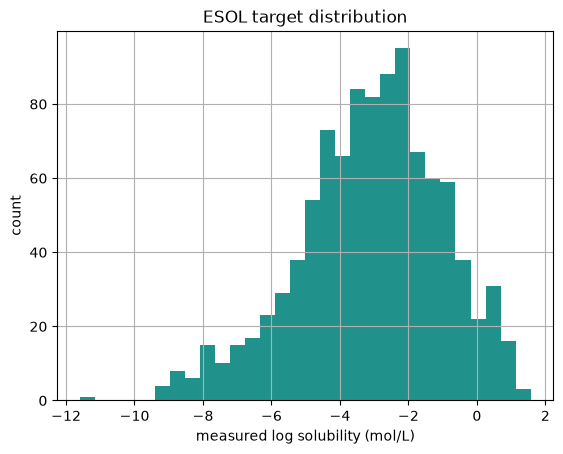

In [4]:
df[TARGET].hist(bins=30, color=plt.cm.viridis(0.5))
plt.xlabel("measured log solubility (mol/L)")
plt.ylabel("count")
plt.title("ESOL target distribution")
plt.show()

## Step 1 — Dataset splitting

We start here because splitting only touches the SMILES and the target — it doesn't depend on a
model or a representation, so there's no reason to decide those first. Every split function
returns **two** sets: `train` and `val`. We're deliberately doing everything in this tutorial
with a single train/val split, at a small scale, so the whole workflow — including the
hyperparameter search in Step 4 — stays easy to see end to end. `val` is the only held-out data
this notebook has access to; there's a genuinely fresh evaluation set too, but it's kept
completely outside this notebook, for later.

How we split molecules changes what our evaluation actually measures. Four options are
implemented in `utils/splitting.py`, each targeting ~20% val (train gets the rest):

- **`random`** — a plain i.i.d. shuffle-and-split. No relationship between molecules is considered.
- **`scaffold`** — molecules are grouped by [Bemis-Murcko scaffold](https://en.wikipedia.org/wiki/Bemis%E2%80%93Murcko_scaffold) (their shared ring/core structure); whole scaffold groups go to train or val, so near-identical molecules can't leak across the split.
- **`kmeans`** — molecules are clustered by *Euclidean* distance between fingerprint vectors (KMeans), and whole clusters are held out for val.
- **`butina`** — molecules are clustered by *Tanimoto* similarity between fingerprints ([Butina clustering](https://www.rdkit.org/docs/Cookbook.html#clustering-molecules), the standard cheminformatics notion of "similar molecule"), and whole clusters are held out for val.

`kmeans` and `butina` both aim to test extrapolation to structurally distinct
regions of chemical space, but they can disagree with each other: two molecules "close" by
Euclidean distance aren't guaranteed to be "close" by Tanimoto similarity, especially near cluster
boundaries.

Rather than picking one blind, run the cell below to compute **all four splits** — each one is
called explicitly, with a short message when it's done, so you can see exactly which computation
is happening and how long each one takes.

Running random_split...
  done — 804 train / 200 val
Running scaffold_split...
  done — 840 train / 164 val
Running kmeans_split...
  done — 841 train / 163 val
Running butina_split...
  done — 851 train / 153 val


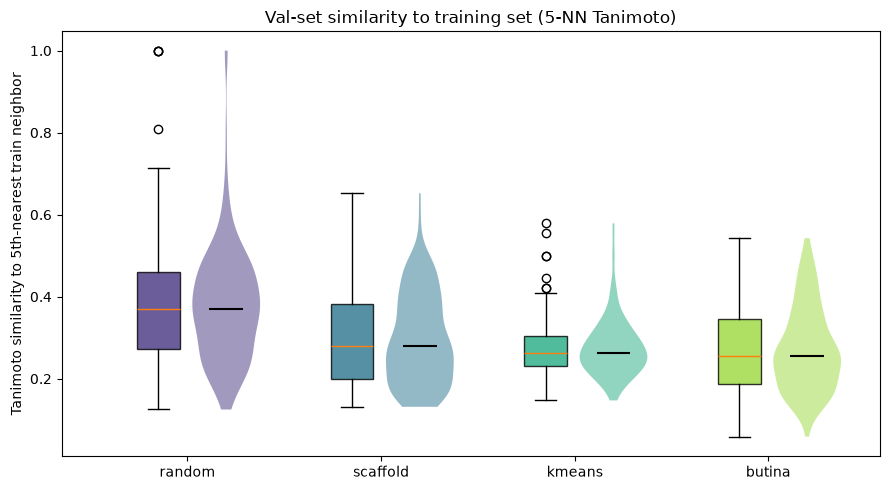

random    : median=0.370  mean=0.380
scaffold  : median=0.279  mean=0.296
kmeans    : median=0.263  mean=0.276
butina    : median=0.256  mean=0.272


In [5]:
print("Running random_split...")
random_train_idx, random_val_idx = random_split(df, val_size=0.2, seed=42)
print(f"  done — {len(random_train_idx)} train / {len(random_val_idx)} val")

print("Running scaffold_split...")
scaffold_train_idx, scaffold_val_idx = scaffold_split(df, val_size=0.2, seed=42)
print(f"  done — {len(scaffold_train_idx)} train / {len(scaffold_val_idx)} val")

print("Running kmeans_split...")
kmeans_train_idx, kmeans_val_idx = kmeans_split(df, val_size=0.2, seed=42)
print(f"  done — {len(kmeans_train_idx)} train / {len(kmeans_val_idx)} val")

print("Running butina_split...")
butina_train_idx, butina_val_idx = butina_split(df, val_size=0.2, seed=42)
print(f"  done — {len(butina_train_idx)} train / {len(butina_val_idx)} val")

splits = {
    "random": (random_train_idx, random_val_idx),
    "scaffold": (scaffold_train_idx, scaffold_val_idx),
    "kmeans": (kmeans_train_idx, kmeans_val_idx),
    "butina": (butina_train_idx, butina_val_idx),
}


nn_sim_stats = nearest_neighbor_similarity(df, splits, k=5)

Before picking one to focus on, compare all four at once: for each split, how Tanimoto-similar
is each val molecule to its 5th-nearest neighbor in that split's training set? A high similarity
means val molecules typically have several close analogs already in train (easy interpolation);
a low similarity means the split is testing genuine extrapolation to unfamiliar chemistry.

Now pick one of the four to inspect more closely.

Using scaffold: 840 train / 164 val


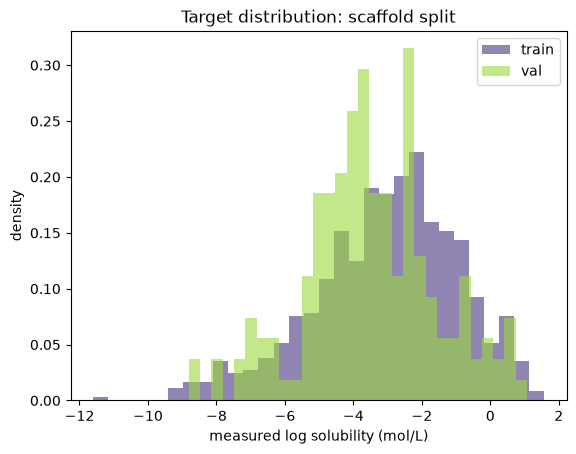

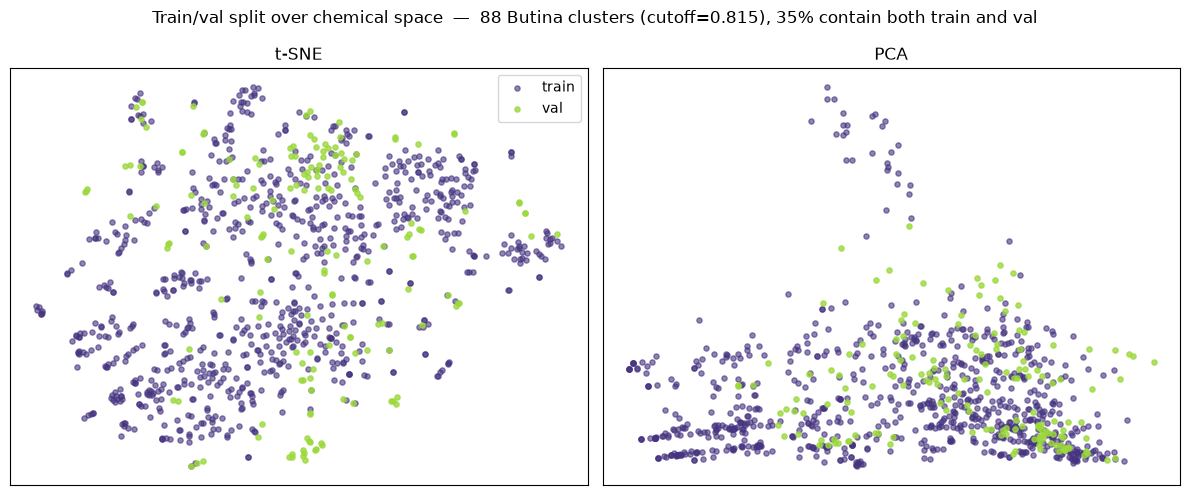

31/88 Butina clusters (35%) contain both train and val molecules.


In [ ]:
# ---- YOUR CHOICE ----
SPLIT_METHOD = "random"  # options: "random", "scaffold", "kmeans", "butina"
# ----------------------

train_idx, val_idx = splits[SPLIT_METHOD]
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
y_train = df[TARGET].values[train_idx]
y_val = df[TARGET].values[val_idx]

print(f"Using {SPLIT_METHOD}: {len(train_idx)} train / {len(val_idx)} val")

plt.hist(y_train, bins=30, alpha=0.6, label="train", density=True, color=TRAIN_COLOR)
plt.hist(y_val, bins=30, alpha=0.6, label="val", density=True, color=VAL_COLOR)
plt.xlabel("measured log solubility (mol/L)")
plt.ylabel("density")
plt.legend()
plt.title(f"Target distribution: {SPLIT_METHOD} split")
plt.show()

split_stats = low_dimensional_representation(df, train_idx, val_idx)

**Discuss:**
- Do train and val look like they come from the same distribution (histogram) and occupy the same regions of chemical space (t-SNE/PCA)?
- What fraction of Butina clusters contain both train and val molecules? What would you expect that number to be for each split method, and does the plot match?
- Try switching `SPLIT_METHOD` to `kmeans` and re-run from there — both it and `butina` "hold out whole clusters," so why doesn't `kmeans` also drive the mixed-cluster fraction to 0%?
- With `scaffold` or either `cluster_*` method, are you testing *interpolation* (molecules similar to what the model has seen) or *extrapolation* (genuinely new chemistry)?
- Which split would you trust more as an estimate of performance on molecules made in a lab next year?

## Step 2 — Model choice

Now that the split is fixed, decide which model to train. This choice determines whether
hand-crafting features (Step 3) is even part of the workflow. Two options are implemented in
`utils/models.py`:

- **`random_forest`** — a classical ML model. It needs a fixed-size feature vector per molecule,
  which means *you* have to decide how to turn a molecule into numbers (Step 3).
- **`chemprop`** — a message-passing graph neural network (MPNN) that learns its own representation
  directly from the molecular graph, end to end, while training. It doesn't need a hand-crafted
  feature vector from Step 3 to get started — but it isn't feature-blind either; see Step 3 for
  what it uses by default and how to extend it.

Pick one below. (Step 4 trains two configurations as a quick search, so budget a bit more time if you pick `chemprop` — each run takes ~10-20 seconds.)

In [ ]:
# ---- YOUR CHOICE ----
MODEL = "chemprop"  # options: "random_forest", "chemprop"
# ----------------------

print(f"Selected model: {MODEL}")
if MODEL == "chemprop":
    print("Chemprop learns its own representation from the molecular graph — Step 3's functions won't apply, but see Step 3 for its default features.")

Selected model: random_forest


**Discuss:**
- Random Forest is trained on a fixed feature vector — what does that assume about the features you'll pick in Step 3?
- Chemprop trains directly on the molecular graph. What does it need *more* of (data, compute, time) to make up for not having hand-crafted features?
- If you only had 50 molecules instead of ~1,000, would your choice of model change?

## Step 3 — Representation

For `random_forest`, pick how to turn a molecule into numbers. Three options are
implemented in `utils/representations.py`:

- **`morgan`** — Morgan (circular) fingerprints: a 2048-bit vector encoding which local substructures are present.
- **`maccs`** — MACCS keys: a fixed 166-bit vector, each bit a specific, human-named structural pattern (e.g. "has a ring of size 6").
- **`rdkit_descriptors`** — 217 global physicochemical descriptors: molecular weight, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, ring counts...

**If you picked `chemprop` in Step 2, these three functions don't apply to it** — but that doesn't
mean representation is irrelevant to Chemprop. It already makes a representation choice by
default (a fixed set of per-atom and per-bond features it builds the molecular graph from), and,
like the options above, that default can be swapped out or extended with your own hand-crafted
features. See the [Chemprop v2 documentation](https://chemprop.readthedocs.io/en/latest/) for the
full set of options (`--molecule-featurizers`, `--descriptors-path`, `--atom-features-path`,
`--bond-features-path`, and more) — most are only exposed via the CLI/config, not (yet) wired up
in `utils/models.py`'s `run_chemprop`.

Chemprop v2's **default** per-atom (node) and per-bond (edge) features, verified against the
installed `chemprop==2.3.1` (`chemprop.featurizers.atom.MultiHotAtomFeaturizer.v2()` /
`chemprop.featurizers.bond.MultiHotBondFeaturizer()`):

- **Node (atom) features — 72 values per atom:** atomic number (one-hot, H through Kr plus
  iodine), degree, formal charge, chiral tag, number of attached hydrogens, hybridization
  (s / sp / sp² / sp²d / sp³ / sp³d / sp³d²), aromaticity, and atomic mass.
- **Edge (bond) features — 14 values per bond:** a "null" padding bit, bond type
  (single/double/triple/aromatic), whether it's conjugated, whether it's in a ring, and its
  stereochemistry (E/Z or none).

Pick one below (ignored if `MODEL == "chemprop"`).

In [8]:
# ---- YOUR CHOICE ----
REPRESENTATION = "morgan"  # options: "morgan", "maccs", "rdkit_descriptors"
# ----------------------

if MODEL == "chemprop":
    print("MODEL = 'chemprop' — it builds its own representation from the graph, so this choice will be ignored in Step 4.")
    X_train = X_val = None
else:
    featurize = REPRESENTATIONS[REPRESENTATION]
    X_train = featurize(train_df["smiles"].tolist())
    X_val = featurize(val_df["smiles"].tolist())
    print(f"{REPRESENTATION}: X_train.shape = {X_train.shape}")

morgan: X_train.shape = (840, 2048)


**Discuss:**
- How many numbers describe each molecule here? What structural information might this representation lose?
- Would two molecules a chemist considers very similar end up with similar feature vectors?
- Could you look at this feature vector and explain *why* the model made a given prediction?
- We do not have the time to manually optimise chemprop's features, but what would you like to change if given the opportunity?

## Step 4 — Train

Train `MODEL` on the `SPLIT_METHOD` split, using the `REPRESENTATION` features (unless you picked
`chemprop`, which trains directly on SMILES). Rather than training once with fixed settings, run
a **quick hyperparameter search**: try just two values of one hyperparameter (enough to show
the idea, not a real search), each trained on `train` and scored on `val` — the only held-out
data this notebook has. We keep whichever configuration scores best on `val`.

We're deliberately stopping there. Reporting a final "how good is our model" number is a separate
step, on separate data, that comes later — not something this notebook does for you.

In [9]:
if MODEL == "chemprop":
    # Chemprop's "representation learning" is, in effect, its own version of Step 3 —
    # it folds feature-crafting into the model rather than doing it by hand.
    param_grid = [{"depth": 2}, {"depth": 4}]
    trials = []
    for params in param_grid:
        r = run_chemprop(train_df, val_df, target_col=TARGET, epochs=15, **params)
        trials.append((params, r))
        print(f"  {params}: val RMSE = {r['rmse']:.3f}, R2 = {r['r2']:.3f}")
    label = f"{MODEL} ({SPLIT_METHOD} split, learned representation)"

else:  # random_forest
    param_grid = [{"n_estimators": 100}, {"n_estimators": 300}]
    trials = []
    for params in param_grid:
        r = MODEL_RUNNERS[MODEL](X_train, y_train, X_val, y_val, **params)
        trials.append((params, r))
        print(f"  {params}: val RMSE = {r['rmse']:.3f}, R2 = {r['r2']:.3f}")
    label = f"{MODEL} ({SPLIT_METHOD} split, {REPRESENTATION} representation)"

best_params, result = min(trials, key=lambda pr: pr[1]["rmse"])
print()
print(f"Best config: {best_params}")
print(label)
print(f"val: RMSE = {result['rmse']:.3f}   R2 = {result['r2']:.3f}")

  {'n_estimators': 100}: val RMSE = 1.544, R2 = 0.356
  {'n_estimators': 300}: val RMSE = 1.556, R2 = 0.346

Best config: {'n_estimators': 100}
random_forest (scaffold split, morgan representation)
val: RMSE = 1.544   R2 = 0.356


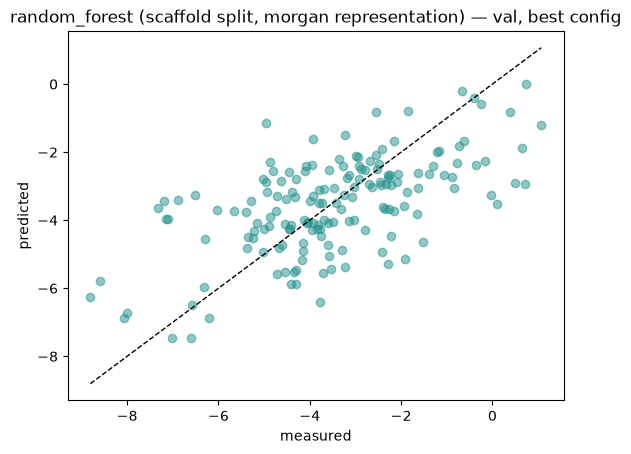

In [10]:
y_pred = result["y_pred"]
lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
plt.scatter(y_val, y_pred, alpha=0.5, color=plt.cm.viridis(0.5))
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("measured")
plt.ylabel("predicted")
plt.title(f"{label} — val, best config")
plt.show()

**Discuss:**
- How does your best val RMSE/R² compare to what your neighbor got with a different choice at any step?
- Random Forest only ever sees the Step 3 features — if performance is poor, is that the model's fault or the representation's?
- Chemprop folded feature-crafting into the model itself. Did it do better or worse than the hand-crafted features here? (Hint: ESOL's target was historically fit using a formula built from LogP, molecular weight, and aromaticity — some of the exact descriptors in `rdkit_descriptors`.) What are the benefits and drawbacks of letting a model *learn* its own representation instead of hand-designing one?
- You just picked a configuration because it scored best on `val` — the exact thing that makes `val` stop being a fresh, unbiased evaluation. If the grid had 20 configurations instead of 2, would you trust the winning val score *more* or *less*? What does that imply about the score you'd get by re-evaluating this same model on data it (and this search) never saw at all?

## Step 5 — Evaluation

So far you've handcrafted a model that performs well on a *single* validation set. That tells
you almost nothing about whether it'll extrapolate to molecules it hasn't influenced in any
way — you tuned choices in Step 4 specifically to make it look good on that one `val`.

To find out, we now run a proper **3×3 nested cross-validation**, reusing the exact choices
you've already made — `SPLIT_METHOD`, `MODEL`, `REPRESENTATION`, and the hyperparameter grid
from Step 4 — just applied repeatedly instead of once:

- The full dataset is partitioned into **3 outer test folds**, grouped the same way
  `SPLIT_METHOD` groups molecules (whole scaffolds/clusters kept together, so a test fold can't
  quietly contain near-duplicates of training molecules).
- For each outer fold, the *other* 2/3 of the data is partitioned again into **3 inner
  train/val splits** — the same kind of split as Step 1, just repeated.
- For each inner split: repeat Step 4's hyperparameter search on inner-train/inner-val, keep
  whichever config scores best on inner-val, and evaluate *that* model on the outer test
  fold — data it never saw and never influenced, at any point.

That gives **3 independently-trained models per outer test fold**, so instead of one number per
fold we get a small distribution: 3 models, each optimized completely independently, all scored
against the exact same held-out molecules. Below, R² and Spearman rank correlation are plotted
per outer fold as a "box plot" — in quotes, because 3 points is a *very* small sample; treat it
as a rough spread, not a real distribution, and look at the actual dots, not just the box.

This trains 9 models end to end (3 outer × 3 inner, plus one retrain per inner split for
`chemprop` to get real test predictions) instead of 25, trading some of the spread's resolution
for speed — a good deal faster than the full 5×5 version, though `chemprop` still takes a while.
All 9 trained models are kept around afterward (as `ensemble`) — Step 6 reuses them directly, no
retraining.

In [11]:
nested = nested_cv_splits(df, method=SPLIT_METHOD, k_outer=3, k_inner=3, seed=42)

cv_results = []  # one row per (outer fold, inner split)
ensemble = []  # the 9 trained models themselves, reused by Step 6

for outer_i, fold in enumerate(nested):
    test_idx = fold["test_idx"]
    outer_test_df = df.iloc[test_idx].reset_index(drop=True)
    y_outer_test = df[TARGET].values[test_idx]
    if MODEL != "chemprop":
        X_outer_test = REPRESENTATIONS[REPRESENTATION](outer_test_df["smiles"].tolist())

    print(f"Outer test fold {outer_i} ({len(test_idx)} molecules):")
    for inner_j, (in_train_idx, in_val_idx) in enumerate(fold["inner_splits"]):
        in_train_df = df.iloc[in_train_idx].reset_index(drop=True)
        in_val_df = df.iloc[in_val_idx].reset_index(drop=True)
        y_in_train = df[TARGET].values[in_train_idx]
        y_in_val = df[TARGET].values[in_val_idx]

        if MODEL == "chemprop":
            # Select the best config on inner-val only (same as Step 4)...
            trials = [(p, run_chemprop(in_train_df, in_val_df, target_col=TARGET, epochs=15, **p)) for p in param_grid]
            best_params, _ = min(trials, key=lambda pr: pr[1]["rmse"])
            # ...then retrain with that config to get real predictions on the outer test fold.
            best = run_chemprop(in_train_df, in_val_df, test_df=outer_test_df, target_col=TARGET, epochs=15, **best_params)
            y_pred = best["y_pred"]
            ensemble.append({"model": None, "work_dir": best["work_dir"]})
        else:
            X_in_train = REPRESENTATIONS[REPRESENTATION](in_train_df["smiles"].tolist())
            X_in_val = REPRESENTATIONS[REPRESENTATION](in_val_df["smiles"].tolist())
            trials = [(p, MODEL_RUNNERS[MODEL](X_in_train, y_in_train, X_in_val, y_in_val, **p)) for p in param_grid]
            best_params, best = min(trials, key=lambda pr: pr[1]["rmse"])
            y_pred = best["model"].predict(X_outer_test)
            ensemble.append({"model": best["model"], "work_dir": None})

        r2 = r2_score(y_outer_test, y_pred)
        rho = spearmanr(y_outer_test, y_pred).correlation
        cv_results.append({"outer_fold": outer_i, "inner_split": inner_j, "best_params": best_params, "r2": r2, "spearman": rho})
        print(f"  inner {inner_j}: best={best_params}  R2={r2:.3f}  spearman={rho:.3f}")

cv_df = pd.DataFrame(cv_results)
print(f"\nDone: {len(cv_df)} models trained across {cv_df['outer_fold'].nunique()} outer test folds, {len(ensemble)} models kept in `ensemble` for Step 6.")

Outer test fold 0 (268 molecules):
  inner 0: best={'n_estimators': 300}  R2=-0.611  spearman=0.428
  inner 1: best={'n_estimators': 300}  R2=-0.275  spearman=0.599
  inner 2: best={'n_estimators': 300}  R2=-0.297  spearman=0.602
  inner 3: best={'n_estimators': 300}  R2=-0.433  spearman=0.596
  inner 4: best={'n_estimators': 300}  R2=-0.323  spearman=0.577
Outer test fold 1 (251 molecules):
  inner 0: best={'n_estimators': 100}  R2=-1.593  spearman=0.285
  inner 1: best={'n_estimators': 100}  R2=-0.633  spearman=0.317
  inner 2: best={'n_estimators': 100}  R2=-1.764  spearman=0.358
  inner 3: best={'n_estimators': 300}  R2=-1.478  spearman=0.306
  inner 4: best={'n_estimators': 100}  R2=-1.448  spearman=0.300
Outer test fold 2 (162 molecules):
  inner 0: best={'n_estimators': 300}  R2=0.321  spearman=0.714
  inner 1: best={'n_estimators': 100}  R2=0.509  spearman=0.810
  inner 2: best={'n_estimators': 300}  R2=0.290  spearman=0.676
  inner 3: best={'n_estimators': 300}  R2=0.305  spea

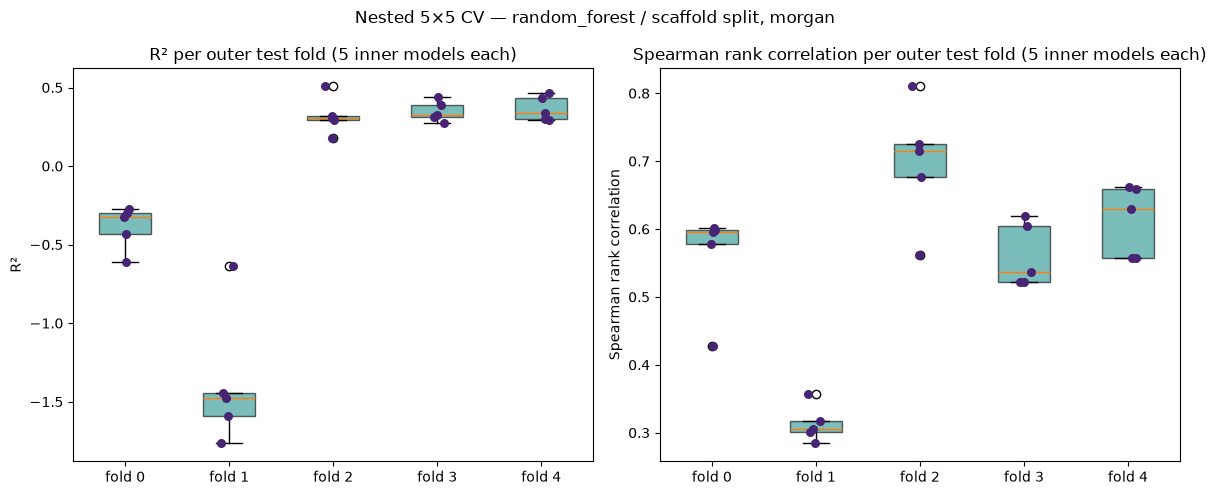

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
n_outer = cv_df["outer_fold"].nunique()
positions = np.arange(1, n_outer + 1)

for ax, metric, title in [(axes[0], "r2", "R\u00b2"), (axes[1], "spearman", "Spearman rank correlation")]:
    data = [cv_df.loc[cv_df["outer_fold"] == i, metric].values for i in range(n_outer)]
    box = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True, showfliers=False)
    for patch in box["boxes"]:
        patch.set_facecolor(plt.cm.viridis(0.5))
        patch.set_alpha(0.6)
    for i, vals in enumerate(data):
        jitter = np.random.RandomState(i).uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(np.full(len(vals), positions[i]) + jitter, vals, color=plt.cm.viridis(0.1), zorder=3, s=30)
    ax.set_xticks(positions)
    ax.set_xticklabels([f"fold {i}" for i in range(n_outer)])
    ax.set_ylabel(title)
    ax.set_title(f"{title} per outer test fold (3 inner models each)")

extra = f", {REPRESENTATION}" if MODEL != "chemprop" else ""
fig.suptitle(f"Nested 3\u00d73 CV \u2014 {MODEL} / {SPLIT_METHOD} split{extra}")
plt.tight_layout()
plt.show()

**Discuss:**
- Look at the spread *within* a single test fold (3 dots, one box). How much does performance
  vary just from which 2/3 of the data the model happened to train/tune on?
- Now look *across* test folds — do some outer folds look consistently harder than others?
  What would make one fold of molecules intrinsically harder to predict than another?
- Compare this spread to the single val number you got in Step 4. Was that number near the
  middle of this distribution, or was it optimistic/pessimistic luck?
- `SPLIT_METHOD` controls how *both* the outer test folds and the inner train/val splits are
  built. If you used `random` here instead of `scaffold`/`butina`, would you expect the spread
  to look wider or narrower — and would the R²/Spearman *level* look better or worse?
- With only 3 points per box, how much would you trust a claim like "fold 2 is harder than fold
  0"? What would you need to be more confident?

## Step 6 — Application

Time to use what you built. `data/real.csv` is 113 molecules held out of this entire tutorial
from the very start — nothing in Steps 0-5 has ever seen them, trained on them, or been tuned
to look good on them. Pretend they just arrived from the lab.

We apply the **full ensemble of 9 models from Step 5** — not just one model. The same way the
Step 5 box plots gave you a spread instead of a single number, the ensemble gives each molecule
in `real.csv` 9 predictions instead of one: a mean (the ensemble's best guess) and a spread
(how much the 9 models disagree with each other, which is itself informative — high disagreement
usually means "this molecule doesn't look like anything the models were confident about").

`real.csv` is genuinely new data, so it needs the same cleaning pipeline as Step 0 before
anything can be done with it — a model can't be handed raw SMILES it's never had to deal with
consistently. Run the cell below to load and clean it.

In [13]:
real_df = pd.read_csv("data/real.csv")
print(f"Loaded {len(real_df)} molecules from data/real.csv")

real_df = remove_invalid_smiles(real_df)
real_df = canonicalize_smiles(real_df)
real_df = remove_salts(real_df)
real_df = remove_stereochemistry(real_df)
real_df = remove_duplicates(real_df, target_col=TARGET)

print(f"{len(real_df)} molecules after cleaning")

Loaded 113 molecules from data/real.csv
remove_invalid_smiles: removed 0 unparseable row(s), 113 remain
canonicalize_smiles: rewrote 74 SMILES into canonical form
remove_salts: stripped a salt/counterion from 0 molecule(s)
remove_stereochemistry: 0 molecule(s) had exactly 1 tetrahedral stereocenter removed, 0 molecule(s) had 2+ tetrahedral stereocenters removed, 1 molecule(s) had E/Z (double-bond) stereochemistry removed
remove_duplicates: removed 2 duplicate row(s) (2 duplicate molecule(s)) — 0 group(s) agreed on 'measured_log_solubility_mol_per_L', 2 group(s) disagreed
111 molecules after cleaning


In [14]:
if MODEL == "chemprop":
    all_preds = np.stack([predict_chemprop(entry["work_dir"], real_df, smiles_col="smiles") for entry in ensemble])
else:
    X_real = REPRESENTATIONS[REPRESENTATION](real_df["smiles"].tolist())
    all_preds = np.stack([entry["model"].predict(X_real) for entry in ensemble])

print(f"all_preds.shape = {all_preds.shape}  ({all_preds.shape[0]} models x {all_preds.shape[1]} molecules)")

y_real = real_df[TARGET].values
pred_mean = all_preds.mean(axis=0)
pred_std = all_preds.std(axis=0)

ensemble_r2 = r2_score(y_real, pred_mean)
ensemble_spearman = spearmanr(y_real, pred_mean).correlation
print(f"Ensemble mean vs. real.csv: R2 = {ensemble_r2:.3f}   spearman = {ensemble_spearman:.3f}")

all_preds.shape = (25, 111)  (25 models x 111 molecules)
Ensemble mean vs. real.csv: R2 = 0.544   spearman = 0.753


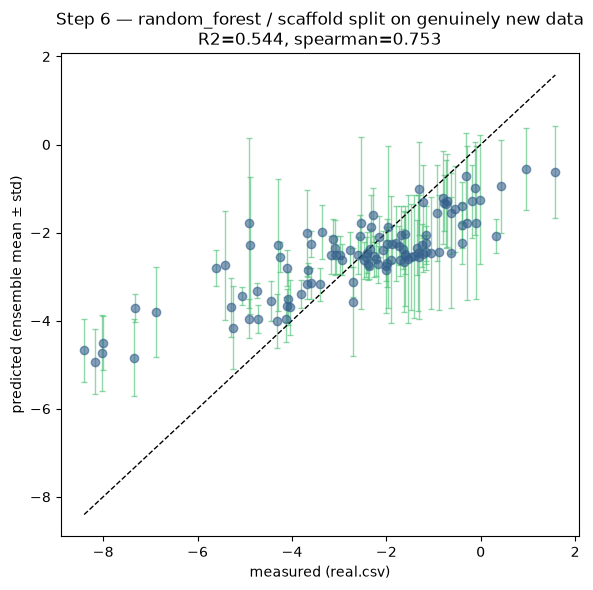

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    y_real, pred_mean, yerr=pred_std, fmt="o", alpha=0.6,
    color=plt.cm.viridis(0.3), ecolor=plt.cm.viridis(0.7), elinewidth=1, capsize=2,
)
lims = [min(y_real.min(), pred_mean.min()), max(y_real.max(), pred_mean.max())]
ax.plot(lims, lims, "k--", linewidth=1)
ax.set_xlabel("measured (real.csv)")
ax.set_ylabel("predicted (ensemble mean \u00b1 std)")
ax.set_title(
    f"Step 6 \u2014 {MODEL} / {SPLIT_METHOD} split on genuinely new data\n"
    f"R2={ensemble_r2:.3f}, spearman={ensemble_spearman:.3f}"
)
plt.tight_layout()
plt.show()

**Discuss:**
- How does this R²/Spearman on `real.csv` compare to the Step 5 box plots? Does it fall inside
  the spread you saw there, or outside it?
- Which molecules have the *widest* error bars (most disagreement between the 9 models)? Pull
  up a couple by SMILES — do they look structurally different from anything in the training
  data? Is that a coincidence?
- If you had to ship this model tomorrow, would you report a single number, or something closer
  to "R² around X on data like this, but Y depending on which molecules you ask about"?
- Every step from 1 onward was a choice you made and could have made differently. Looking at
  everything you've seen today, which single choice — split method, model, representation, or
  hyperparameter grid — would you go back and interrogate first, if you had unlimited time?